In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from scipy.stats import norm

#this sets the size of the plot to something useful
plt.rcParams["figure.figsize"] = (15,10)

In [3]:
#create set of random 100000 data points following a normal distribution about the point 5. Scale determines std dev
d = stats.norm.rvs(loc = 5.0, scale = .01, size = 1000000)

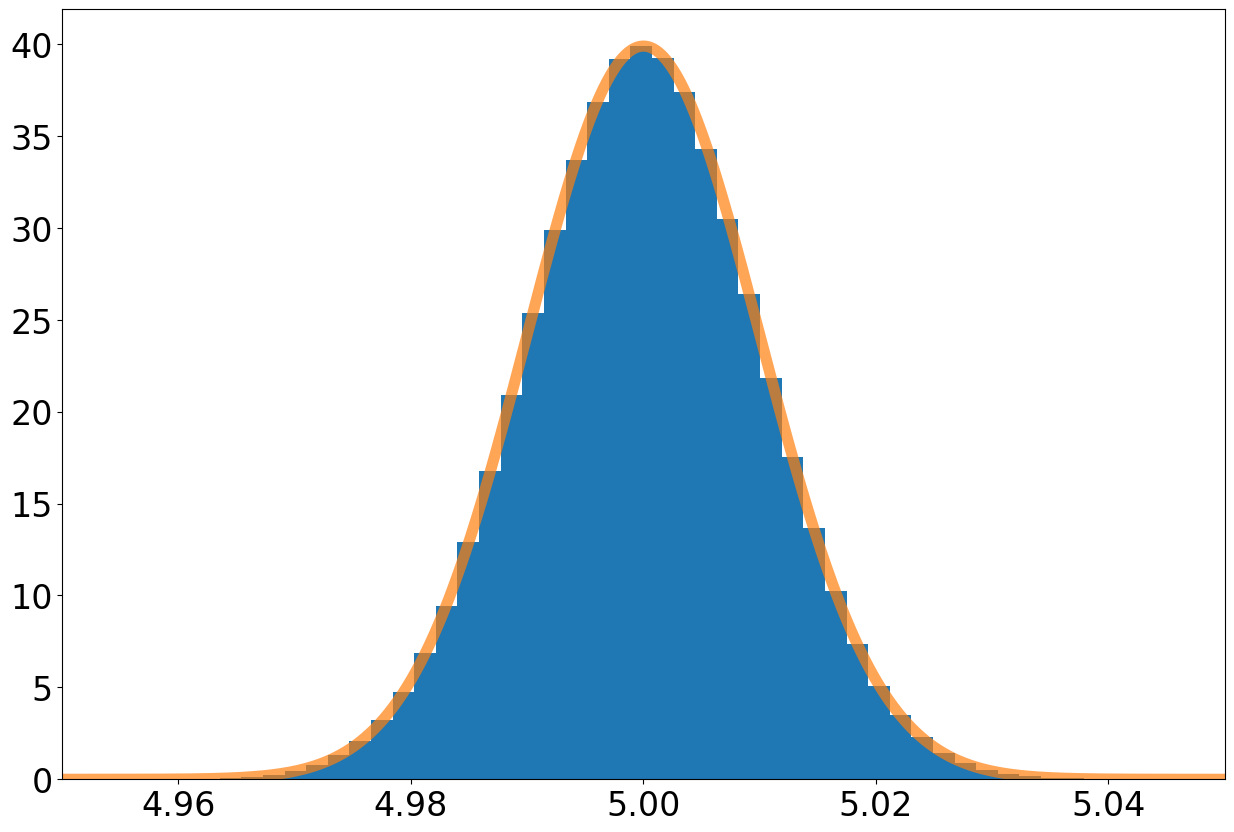

In [4]:
#plot both the random distribution as a histogram and a line following the norm with same std dev and center - the data follows the curve well thanks to many
# data points
fig, ax = plt.subplots(1, 1)
ax.hist(d,50, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([4.95,5.05])
x = np.linspace(4.95,5.05,1000)
ax.plot(x,stats.norm.pdf(x,loc = 5., scale = 0.01),linewidth = 8,alpha = 0.7)
plt.show()

In [5]:
# Define parameters for standard normal distribution
x = 1
mean = 0
std_dev = 1

# Compute the CDF
cdf_value = norm.cdf(x, loc=mean, scale=std_dev)

# Print the result
print(f"CDF value at x={x}: {cdf_value}")

CDF value at x=1: 0.8413447460685429


In [6]:
#^ Above looks good, checking Z table for the normal distribution we see 0.84134 --> the probability that the statistic is between negative infinity and the given z value "x"

In [7]:
# Define parameters for standard normal distribution
x = 0
mean = 0
std_dev = 1

# Compute the CDF
cdf_value = norm.cdf(x, loc=mean, scale=std_dev)

# Print the result
print(f"CDF value at x={x}: {cdf_value}")

CDF value at x=0: 0.5


In [8]:
#^ also as expected, if the mean is at zero for the normal distribution then we would expect half of all values to fall to the left of x

In [9]:
vals = stats.norm.ppf([0.15866, 0.5, 0.84134])
print(vals)

[-0.99998039  0.          0.99998039]


In [10]:
#^ using the norm.ppf to determine the value of sigma, using known values pulled from the z-table. I chose the values associated with -1, 0, and 1 standard
# devaitions. The error is due to rounding done in the z-table. Negativity is associated with values to the left of the median.

In [11]:
# Going to explore raleigh distribution, again set the std dev and point which represents the minimum of the data (in raleigh case)
r = stats.rayleigh.rvs(loc = 5.0, scale = .01, size = 1000000)

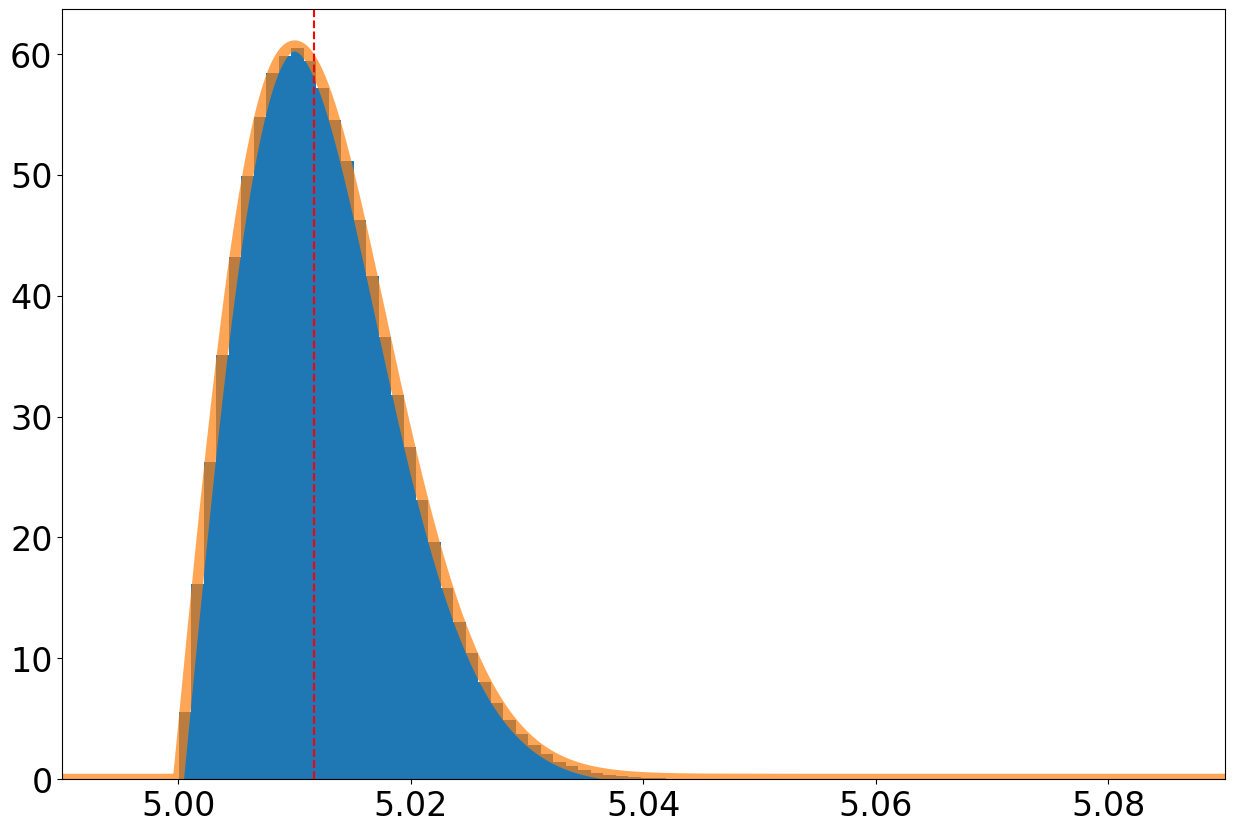

In [12]:
#plot histogram and expected result for given data distribution as for the norm above
fig, ax = plt.subplots(1, 1)
ax.hist(r,50, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([4.99,5.09])
x = np.linspace(4.99,5.09,1000)
ax.plot(x,stats.rayleigh.pdf(x,loc = 5., scale = 0.01),linewidth = 8,alpha = 0.7)
plt.axvline(x=5.0117, color='red', linestyle='--')
plt.show()

In [13]:
#^ r is a collection of random points in a rayleigh distribution. The histogram plots the r distribution for each data sub-range, and the
# drawn orange line is the rayleigh distribution centered at 5, confirming the collection of random data matches the expected distribution. I drew a red line to
# show where the probability value is .5, note the data is skewed, which is typical of a raleigh distribution.

In [14]:
# I would like to know the likelihood that the data falls at or below the point 5.02 --> the integral of the given rayleigh function from the start of the data
# to the given point.

In [15]:
sigma = stats.rayleigh.cdf([5.02], loc=5, scale=.01)
print (sigma)

[0.86466472]


In [16]:
#I used this to find where to draw the red line
half = stats.rayleigh.ppf([.5], loc=5, scale=.01)
print (half)

[5.0117741]


In [17]:
#Testing that the probability is .5 at the expected point
sigma2 = stats.rayleigh.cdf(half, loc=5, scale=.01)
print (sigma2)

[0.5]


In [18]:
sigma3 = stats.rayleigh.cdf([5.001], loc=5, scale=.01)
print (sigma3)

[0.00498752]


In [19]:
#finding the standard deviation
stddev = stats.rayleigh.std(loc=5,scale=.01)
print (stddev)

0.0065513637756203355


In [20]:
#rayleigh CDF is affected by x position and scale factor
onedev = stats.rayleigh.cdf(half+stddev, loc=5, scale=.01)
print (onedev)

[0.81346067]


In [39]:
#messing around with another rayleigh distribution --> noted that scale, which for rayleigh is linearly related to std dev, spreads the data out more
r2 = stats.rayleigh.rvs(loc = 0, scale = 1, size = 1000000)

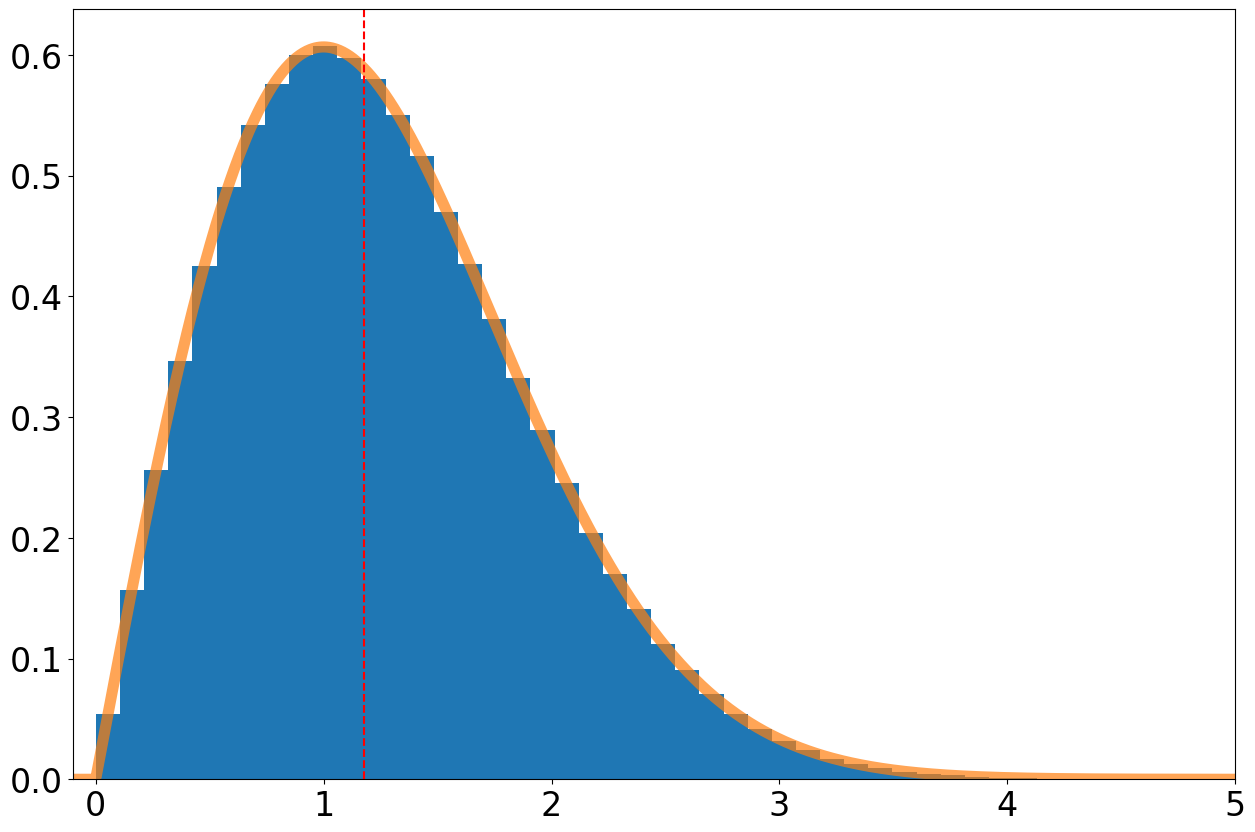

In [50]:
fig, ax = plt.subplots(1, 1)
ax.hist(r2,50, density=True)
plt.tick_params(labelsize = 24)
plt.xlim([-.1,5.00])
x = np.linspace(-.1,5,1000)
ax.plot(x,stats.rayleigh.pdf(x,loc = 0, scale = 1),linewidth = 8,alpha = 0.7)
plt.axvline(x=1.1774, color='red', linestyle='--')
plt.show()

In [42]:
#finding .5 for CDF
half2 = stats.rayleigh.ppf([.5], loc=0, scale=1)
print (half2)

[1.17741002]
